# 1. K-Nearest Neighbors (KNN) Regression
Concept: Non-parametric. Predicts $y$ by averaging the "neighbors" in the feature space.

- Distance (Euclidean): $d = \sqrt{\sum (x_i - q_i)^2}$
- Prediction: $\hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i$

Implementation Idea: 

1. Calculate distances from query point to all training points using np.linalg.norm(X - query, axis=1).

2. Use np.argsort() to get indices of the $k$ smallest distances.

3. Return y[indices].mean().

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sales_predictors.csv')

In [11]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [13]:
X = df["TV"]
Y = df["Sales"]

print(X.head(), Y.head())

0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
Name: TV, dtype: float64 0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [55]:
x_max = 300
x_min = 0
query = np.linspace(start=x_min, stop=x_max, num=x_max)
k_color = dict([
    (3,"#0033FF95"),
    (7,"#FFB835"),
    (9,"#004829"),
    (13,"#8B00AE"),
])

def knn(x, y, q, k):
    distance = np.abs(x - q)
    idx_nearest = np.argsort(distance)
    k_nearest = idx_nearest[:k]
    return np.mean(y[k_nearest])

k_values = []
for k in k_color.keys():
    distance_df = [knn(X, Y, q, k) for q in query]
    k_values.append(distance_df)

print(k_values)


[[np.float64(3.366666666666667), np.float64(3.366666666666667), np.float64(3.366666666666667), np.float64(3.366666666666667), np.float64(4.666666666666667), np.float64(4.666666666666667), np.float64(5.8), np.float64(5.933333333333334), np.float64(5.7), np.float64(5.8999999999999995), np.float64(5.8999999999999995), np.float64(6.066666666666666), np.float64(6.066666666666666), np.float64(6.066666666666666), np.float64(6.066666666666666), np.float64(6.533333333333332), np.float64(7.966666666666666), np.float64(7.966666666666666), np.float64(7.233333333333333), np.float64(6.766666666666667), np.float64(7.066666666666666), np.float64(7.066666666666666), np.float64(7.8), np.float64(8.299999999999999), np.float64(8.299999999999999), np.float64(8.4), np.float64(8.933333333333334), np.float64(8.4), np.float64(7.666666666666667), np.float64(7.666666666666667), np.float64(7.900000000000001), np.float64(7.900000000000001), np.float64(7.900000000000001), np.float64(9.200000000000001), np.float64(1

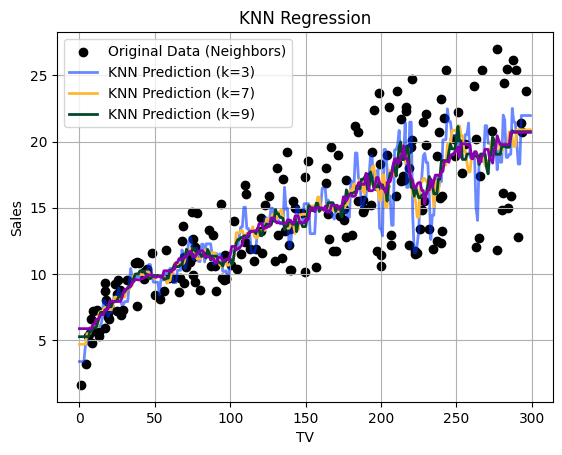

In [57]:

plt.title('KNN Regression')
plt.scatter(X, Y, color="black", label="Original Data (Neighbors)")
plt.grid(visible=True)
plt.xlabel('TV')
plt.ylabel('Sales')

keys = list(k_color.keys())
for k in range(len(keys)):
    value_k = keys[k]
    x_value = k_values[k]
    color = k_color.get(value_k)
    label=f"KNN Prediction (k={value_k})"
    plt.legend(loc='best')
    plt.plot(x_value, color=color, linewidth=2, label=label)

2. Simple Linear Regression (SLR)

Concept: Fits a straight line $y = \beta_0 + \beta_1x$ by minimizing the sum of squared errors.
- Slope ($\hat{\beta}_1$): $\frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$
- Intercept ($\hat{\beta}_0$): $\bar{y} - \hat{\beta}_1\bar{x}$
- Implementation Idea:
1. Calculate means: x_bar, y_bar = x.mean(), y.mean().
2. Solve for $\beta_1$ using np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2).
3. Calculate $\beta_0$.